# Large Language Models (LLMs) for Text Classification Benchmark

**Author:** Alireza Mirzadeh  
**Project:** LLM Text Classification Benchmark  
**Dataset:** Rotten Tomatoes (Hugging Face Datasets)  
**Notebook:** 01 — EDA

---

## Project Overview

This project provides a comprehensive benchmark of text classification techniques, progressing from classical machine learning methods to transformer-based models and large language models (LLMs). The implementation emphasizes reproducibility, modular software design, and rigorous experimental evaluation.

### Project Links

- **GitHub Repository:** *[llm-text-classification-benchmark](https://github.com/Alireza-Mirzadeh/llm-text-classification-benchmark)*

- **LinkedIn:** *[Alireza Mirzadeh](https://www.linkedin.com/in/alireza-mirzadeh/)*

---

# Exploratory Data Analysis (EDA) of the Rotten Tomatoes Sentiment Dataset


## Objective

The objective of this notebook is to explore and understand the Rotten Tomatoes sentiment dataset before developing classification models.

Specifically, we aim to:
- Understand the dataset structure
- Examine class balance
- Analyze review length characteristics
- Explore vocabulary patterns
- Investigate frequent words and n-grams
- Identify challenges that may affect classification performance

The insights obtained from this analysis will guide the design and evaluation of traditional machine learning models, transformer-based models, and large language models in later stages of the project.

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [2]:
from src.data_loader import RottenTomatoesDataLoader

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re

import nltk
nltk.download("stopwords")

from nltk.corpus import stopwords
from nltk.util import ngrams

from collections import Counter

# Plotting style
sns.set_theme(style="whitegrid")

# Make plots larger
plt.rcParams["figure.figsize"] = (10, 6)
FIGURES_DIR = Path("../reports/figures/eda")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/alireza/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
# Load the Rotten Tomatoes dataset
data_manager = RottenTomatoesDataLoader()

# Download the dataset and save it locally
dataset = data_manager.download_dataset()
data_manager.save_dataset_local(dataset)

# Load the dataset from local storage
dataset = data_manager.load_dataset_local()
dataset


2026-07-08 12:51:31,655 - INFO - Downloading dataset: cornell-movie-review-data/rotten_tomatoes
2026-07-08 12:51:31,849 - INFO - HTTP Request: GET https://huggingface.co/api/agent-harnesses "HTTP/1.1 200 OK"
2026-07-08 12:51:31,995 - INFO - HTTP Request: HEAD https://huggingface.co/datasets/cornell-movie-review-data/rotten_tomatoes/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-07-08 12:51:32,027 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/cornell-movie-review-data/rotten_tomatoes/aa13bc287fa6fcab6daf52f0dfb9994269ffea28/README.md "HTTP/1.1 200 OK"
2026-07-08 12:51:32,142 - INFO - HTTP Request: HEAD https://huggingface.co/datasets/cornell-movie-review-data/rotten_tomatoes/resolve/aa13bc287fa6fcab6daf52f0dfb9994269ffea28/rotten_tomatoes.py "HTTP/1.1 404 Not Found"
2026-07-08 12:51:32,144 - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
202

Saving the dataset (0/1 shards):   0%|          | 0/8530 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1066 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1066 [00:00<?, ? examples/s]

2026-07-08 12:51:33,559 - INFO - Dataset saved to /home/alireza/Work/llm-text-classification-benchmark/data/raw/rotten_tomatoes
2026-07-08 12:51:33,560 - INFO - Loading dataset from local_path: /home/alireza/Work/llm-text-classification-benchmark/data/raw/rotten_tomatoes


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8530
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
})

In [4]:
# Inspect Dataset Splits
for split_name, split in dataset.items():
    print(f"{split_name}: {len(split):,} samples")

train: 8,530 samples
validation: 1,066 samples
test: 1,066 samples


In [5]:
# Split the dataset into training set and convert to DataFrame
train_df = dataset["train"].to_pandas()

train_df.head()

,text,label
0,the rock is destined to be the 21st century's ...,1
1,"the gorgeously elaborate continuation of "" the...",1
2,effective but too-tepid biopic,1
3,if you sometimes like to go to the movies to h...,1
4,"emerges as something rare , an issue movie tha...",1


In [6]:
# Inspect Training Set
train_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8530 entries, 0 to 8529
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    8530 non-null   str  
 1   label   8530 non-null   int64
dtypes: int64(1), str(1)
memory usage: 1.1 MB


# Section 1: Initial Observations

The dataset contains movie reviews and corresponding sentiment labels.

Columns:
- `text`: The movie review text
- `label`: The sentiment class

The target variable is binary:

- `0`: Negative sentiment
- `1`: Positive sentiment

No additional metadata is provided in the dataset.

In [7]:
# Dataset Summary table
summary = pd.DataFrame(
    {
        "split": dataset.keys(),
        "Samples": [len(dataset[split]) for split in dataset.keys()],
    }
)

summary

,split,Samples
0,train,8530
1,validation,1066
2,test,1066


In [8]:
# Check for missing values in the training set
missing_count = train_df.isnull().sum()

print(f"Missing values in the training set: \n{missing_count}")

Missing values in the training set: 
text     0
label    0
dtype: int64


In [9]:
# Check for duplicate values in the training set
duplicate_count = train_df.duplicated(subset=["text"]).sum()

print(f"Duplicate reviews: {duplicate_count}")

Duplicate reviews: 0


# Section 2: Data Quality Assessment

The dataset was inspected for missing values and duplicate entries. The results indicate that there are no missing values and no duplicate entries in the training set, suggesting that the dataset is clean and ready for analysis.

In [10]:
# Label Distribution
class_distribution = train_df["label"].value_counts()

print(f"class distribution: \n\n{class_distribution}")

class distribution: 

label
1    4265
0    4265
Name: count, dtype: int64


In [11]:
# Class Distribution Percentages
class_distribution_percent = (
    train_df["label"].value_counts(normalize=True).reset_index()
)

class_distribution_percent.columns = ["label", "percentage"]

class_distribution_percent["percentage"] = class_distribution_percent["percentage"] * 100

print(f"Class distribution percentages: \n\n{class_distribution_percent}")

Class distribution percentages: 

   label  percentage
0      1        50.0
1      0        50.0


2026-07-08 12:51:33,955 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-08 12:51:33,963 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


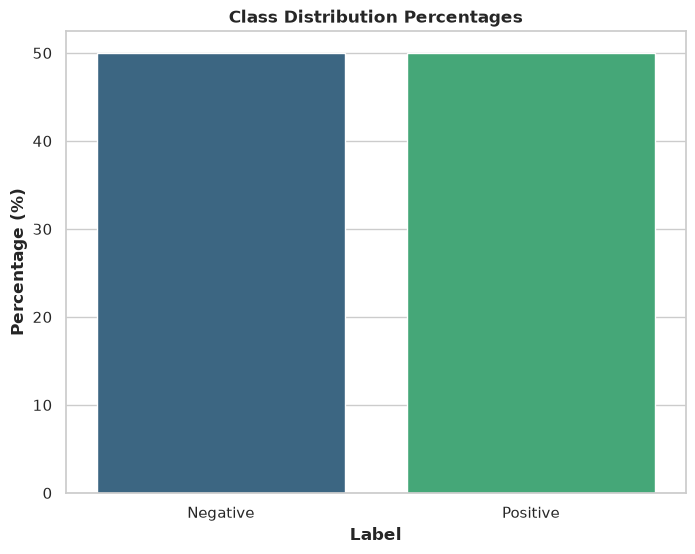

In [12]:
# Bar plot of class distribution
plt.figure(figsize=(8, 6))
sns.barplot(x="label", y="percentage", hue="label", data=class_distribution_percent, palette="viridis", legend=False)

plt.title("Class Distribution Percentages", weight="bold")
plt.xlabel("Label", weight="bold")
plt.ylabel("Percentage (%)", weight="bold")

plt.xticks(ticks=[0, 1], labels=["Negative", "Positive"])

plt.show()

# Interpretation of Class Distribution

The Rotten Tomatoes dataset exhibits a balanced class distribution. This balanced structure makes the dataset suitable for comparing classical machine learning models, transformer-based models, and large language moodels under fair conditions.

# Section 3: Review Length Analysis

In [13]:
# Add character count and word count columns to the training DataFrame

train_df["char_count"] = train_df["text"].str.len()

train_df["word_count"] = train_df["text"].str.split().str.len()

train_df[["text", "char_count", "word_count"]].head()


,text,char_count,word_count
0,the rock is destined to be the 21st century's ...,177,34
1,"the gorgeously elaborate continuation of "" the...",226,39
2,effective but too-tepid biopic,30,4
3,if you sometimes like to go to the movies to h...,89,21
4,"emerges as something rare , an issue movie tha...",111,21


In [14]:
# Summary statistics for character count and word count

train_df[["char_count", "word_count"]].describe().round(2)

,char_count,word_count
count,8530.00,8530.00
mean,113.97,20.99
std,51.05,9.37
min,4.00,1.00
25%,76.00,14.00
50%,111.00,20.00
75%,149.00,27.00
max,267.00,59.00


The statistical analysis of review lengths, measured by both character count and word count, indicates that the Rotten Tomatoes reviews are generally concise. On average, reviews contain approximately 114 characters and 21 words, while the longest review contains 59 words. These findings suggest that sentiment classification must be performed using a relatively limited textual context.

In [15]:
# Review Length Analysis by Label
(
train_df.groupby("label")["word_count"]
.describe()
.round(2)
)

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,4265.0,20.94,9.31,1.0,14.0,20.0,27.0,56.0
1,4265.0,21.05,9.43,2.0,14.0,20.0,27.0,59.0


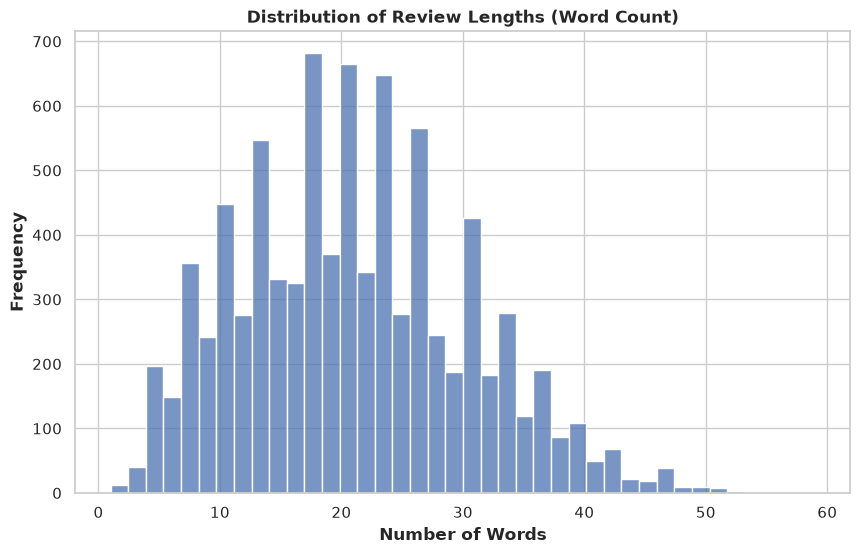

In [16]:
# Histogram of Review Lengths (Word Count)
sns.histplot(
    train_df["word_count"],
    bins=40
)

plt.title("Distribution of Review Lengths (Word Count)", weight="bold")
plt.xlabel("Number of Words", weight="bold")
plt.ylabel("Frequency", weight="bold")

plt.savefig(FIGURES_DIR / "review_length_histogram.png")

plt.show()

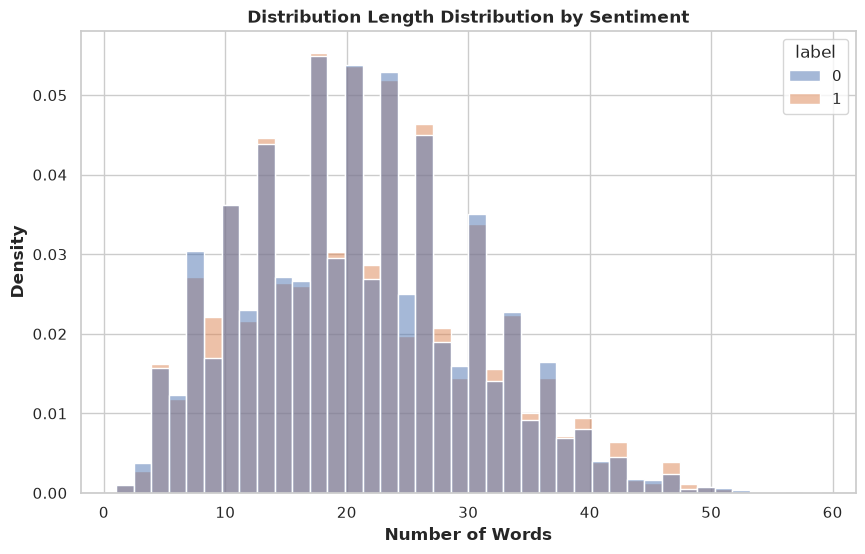

In [17]:
# Histogram of Review Lengths by Label (Word Count)
sns.histplot(
    train_df,
    x="word_count",
    hue="label",
    bins=40,
    stat="density",
    common_norm=False

)

plt.title("Distribution Length Distribution by Sentiment", weight="bold")
plt.xlabel("Number of Words", weight="bold")
plt.ylabel("Density", weight="bold")

plt.savefig(FIGURES_DIR / "review_length_histogram_by_sentiment.png")

plt.show()

2026-07-08 12:51:34,825 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-08 12:51:34,835 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


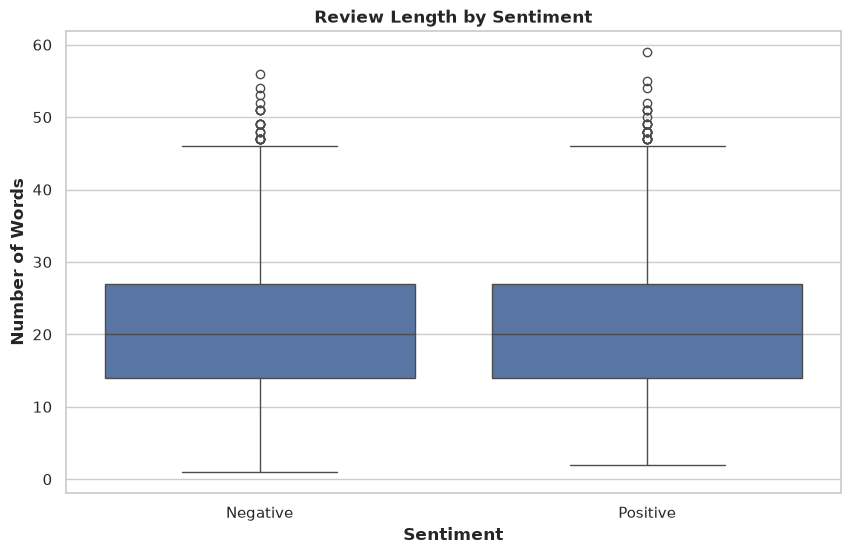

In [18]:
# Boxplot of Review Lengths by Label (Word Count)
sns.boxplot(
    data=train_df,
    x="label",
    y="word_count"
)

plt.title("Review Length by Sentiment", weight="bold")
plt.xlabel("Sentiment", weight="bold")
plt.ylabel("Number of Words", weight="bold")

plt.xticks(
    [0, 1],
    ["Negative", "Positive"]
)

plt.savefig(FIGURES_DIR / "review_length_boxplot_by_sentiment.png")

plt.show()


In [19]:
# Top 5 Longest Reviews
train_df.nlargest(
    5,
    "word_count",
)[["word_count", "label", "text"]]

,word_count,label,text
834,59,1,. . . a sour little movie at its core ; an exp...
4574,56,0,"it won't harm anyone , but neither can i think..."
160,55,1,the film is faithful to what one presumes are ...
1968,54,1,it would be disingenuous to call reno a great ...
5701,54,0,"who are 'they' ? well , they're 'they' . they'..."


In [20]:
# Top 5 Shortest Reviews
train_df.nsmallest(
    5,
    "word_count",
)[["word_count", "label", "text"]]

,word_count,label,text
4852,1,0,obvious
5483,1,0,horrible
26,2,1,spiderman rocks
1540,2,1,delightfully rendered
2241,2,1,surprisingly insightful


# Section 4:Vocabulary Exploration


In [21]:
# Function to clean text data
def clean_text(text):
    """
    Basic preprocessing function for vocabulary analysis

    Args:
        text (str): The input text to be cleaned

    Returns:
        str: The cleaned text
    """

    # Lowercase the text
    text = text.lower()

    # Remove punctuation and special characters
    text = re.sub(r"[^\w\s]", "", text)

    return text



In [22]:
# Apply the clean text function to the training DataFrame
train_df["clean_text"] = train_df["text"].apply(clean_text)

train_df[["text", "clean_text"]].head()

,text,clean_text
0,the rock is destined to be the 21st century's ...,the rock is destined to be the 21st centurys n...
1,"the gorgeously elaborate continuation of "" the...",the gorgeously elaborate continuation of the ...
2,effective but too-tepid biopic,effective but tootepid biopic
3,if you sometimes like to go to the movies to h...,if you sometimes like to go to the movies to h...
4,"emerges as something rare , an issue movie tha...",emerges as something rare an issue movie that...


In [23]:
# Set of English stop words from NLTK
stop_words = set(stopwords.words("english"))


In [24]:
# Function to tokenize text and remove stop words
def tokenize(text):
    """
    Tokenizes the input text into individual words, removing stop words.

    Args:
        text (str): The input text to be tokenized
    
    Returns:
        list: A list of tokens (words) from the input text
    """

    return [
        word
        for word in text.split()
        if word not in stop_words
    ]

In [25]:
# Apply the tokenize function to the training DataFrame
train_df["tokens"] = train_df["clean_text"].apply(tokenize)

In [26]:
# Count the frequency of each word in the training set
all_words = []

for tokens in train_df["tokens"]:
    all_words.extend(tokens)

word_freq = Counter(all_words)

word_freq.most_common(20)

[('film', 1143),
 ('movie', 1029),
 ('like', 573),
 ('one', 564),
 ('story', 370),
 ('even', 305),
 ('much', 299),
 ('good', 296),
 ('comedy', 282),
 ('time', 272),
 ('characters', 270),
 ('films', 260),
 ('way', 237),
 ('little', 233),
 ('make', 227),
 ('funny', 226),
 ('enough', 214),
 ('movies', 212),
 ('makes', 210),
 ('never', 203)]

In [27]:
# Create a DataFrame for the top 20 most common words and their frequencies
top_words_df = pd.DataFrame(
    word_freq.most_common(20),
    columns=["word", "frequency"]
)

top_words_df

,word,frequency
0,film,1143
1,movie,1029
2,like,573
3,one,564
4,story,370
5,even,305
6,much,299
7,good,296
8,comedy,282
9,time,272


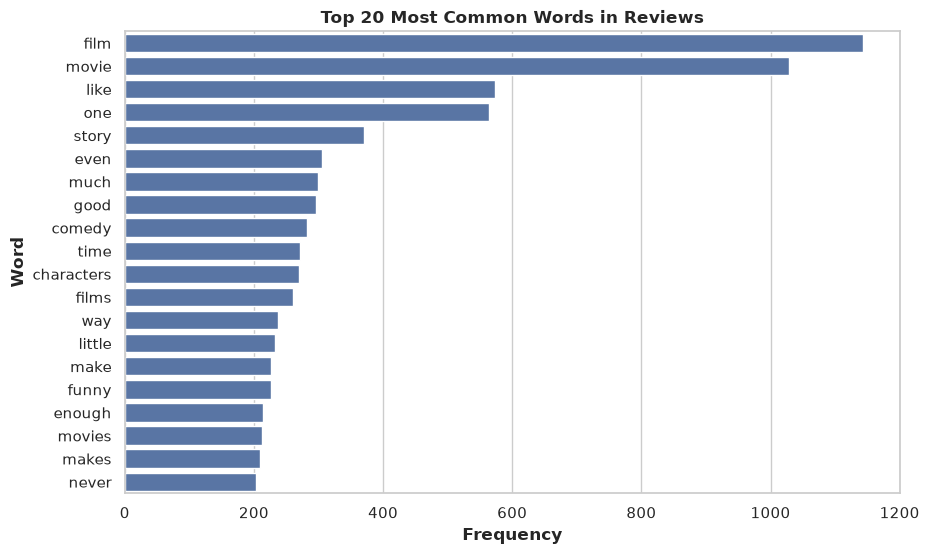

In [28]:
# Bar plot of the top 20 most common words
sns.barplot(
    data=top_words_df,
    x="frequency",
    y="word"
)

plt.title("Top 20 Most Common Words in Reviews", weight="bold")
plt.xlabel("Frequency", weight="bold")
plt.ylabel("Word", weight="bold")

plt.savefig(FIGURES_DIR / "top_20_common_words.png")

plt.show()

In [29]:
# Positive Reviews DataFrame
positive_df = train_df[
    train_df["label"] == 1
]

positive_words = []

for tokens in positive_df["tokens"]:
    positive_words.extend(tokens)

positive_counter = Counter(positive_words)

# Create a DataFrame for the top 20 most common words in positive reviews and their frequencies
positive_top = pd.DataFrame(
    positive_counter.most_common(20),
    columns=["word", "frequency"]
)

print("Top 20 Most Common Words in Positive Reviews:")
positive_top

Top 20 Most Common Words in Positive Reviews:


,word,frequency
0,film,634
1,movie,412
2,one,277
3,like,214
4,story,190
5,comedy,160
6,good,152
7,films,149
8,even,144
9,funny,140


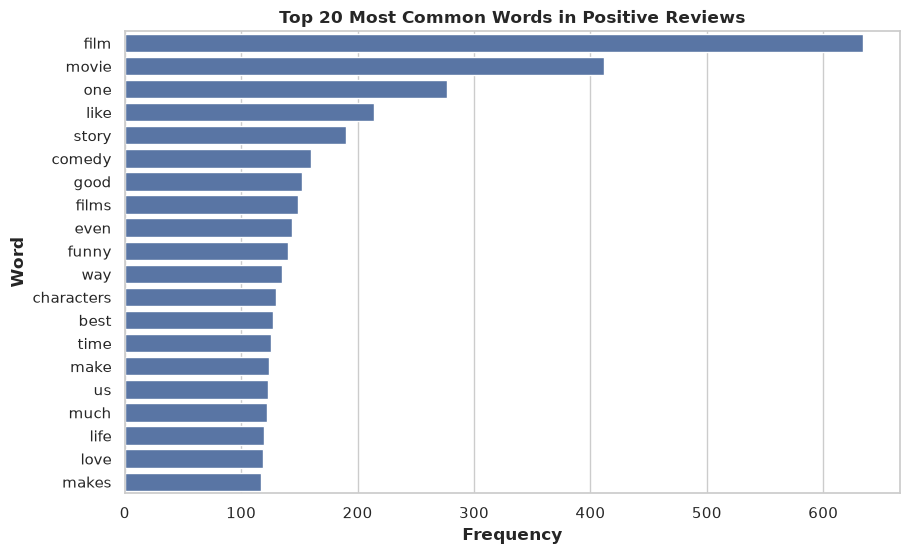

In [30]:
# Bar plot of the top 20 most common words in positive reviews
sns.barplot(
    data=positive_top,
    x="frequency",
    y="word"
)

plt.title("Top 20 Most Common Words in Positive Reviews", weight="bold")
plt.xlabel("Frequency", weight="bold")
plt.ylabel("Word", weight="bold")

plt.savefig(FIGURES_DIR / "top_20_common_words_positive.png")

plt.show()

In [31]:
# Negative Reviews DataFrame
negative_df = train_df[
    train_df["label"] == 0
]

negative_words = []

for tokens in negative_df["tokens"]:
    negative_words.extend(tokens)

negative_counter = Counter(negative_words)

# Create a DataFrame for the top 20 most common words in negative reviews and their frequencies
negative_top = pd.DataFrame(
    negative_counter.most_common(20),
    columns=["word", "frequency"]
)

print("Top 20 Most Common Words in Negative Reviews:")
negative_top


Top 20 Most Common Words in Negative Reviews:


,word,frequency
0,movie,617
1,film,509
2,like,359
3,one,287
4,story,180
5,much,177
6,bad,173
7,even,161
8,time,146
9,good,144


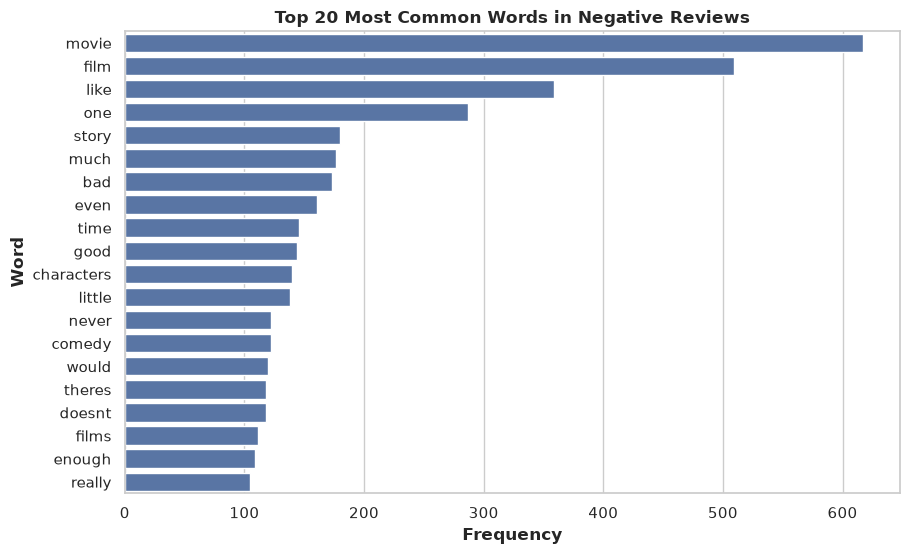

In [32]:
# Bar plot of the top 20 most common words in negative reviews
sns.barplot(
    data=negative_top,
    x="frequency",
    y="word"
)

plt.title("Top 20 Most Common Words in Negative Reviews", weight="bold")
plt.xlabel("Frequency", weight="bold")
plt.ylabel("Word", weight="bold")

plt.savefig(FIGURES_DIR / "top_20_common_words_negative.png")

plt.show()

# Section 5: N-Gram Analysis 

In [33]:
# Function to get the top n-grams from a list of tokenized texts
def get_top_ngrams(tokens_list, n=2, top_n=20):
    """
    Get the top n-grams from a list of tokenized texts.
    
    Args:
        tokens_list (list of list of str): A list where each element is a list of tokens from a text.
        n (int): The size of the n-grams to extract (default is 2 for bigrams).
        top_k (int): The number of top n-grams to return (default is 20).
    Returns:
        List of tuples: A list of the top n-grams and their frequencies, sorted by frequency in descending order.

    """

    all_ngrams = []

    for tokens in tokens_list:
        all_ngrams.extend(ngrams(tokens, n))

    counter = Counter(all_ngrams)

    return pd.DataFrame(
        counter.most_common(top_n),
        columns=["ngram", "frequency"]
    )


In [34]:
# Get the top 20 bigrams from the training set
top_bigrams_df = get_top_ngrams(train_df["tokens"], n=2, top_n=20)

top_bigrams_df.head()

,ngram,frequency
0,"(romantic, comedy)",47
1,"(feels, like)",38
2,"(plays, like)",29
3,"(special, effects)",24
4,"(subject, matter)",23


In [35]:
# Conver the n-grams from tuples to strings for better readability
top_bigrams_df["ngram"] = (
    top_bigrams_df["ngram"]
    .apply(lambda x: " ".join(x))
)

top_bigrams_df.head()

,ngram,frequency
0,romantic comedy,47
1,feels like,38
2,plays like,29
3,special effects,24
4,subject matter,23


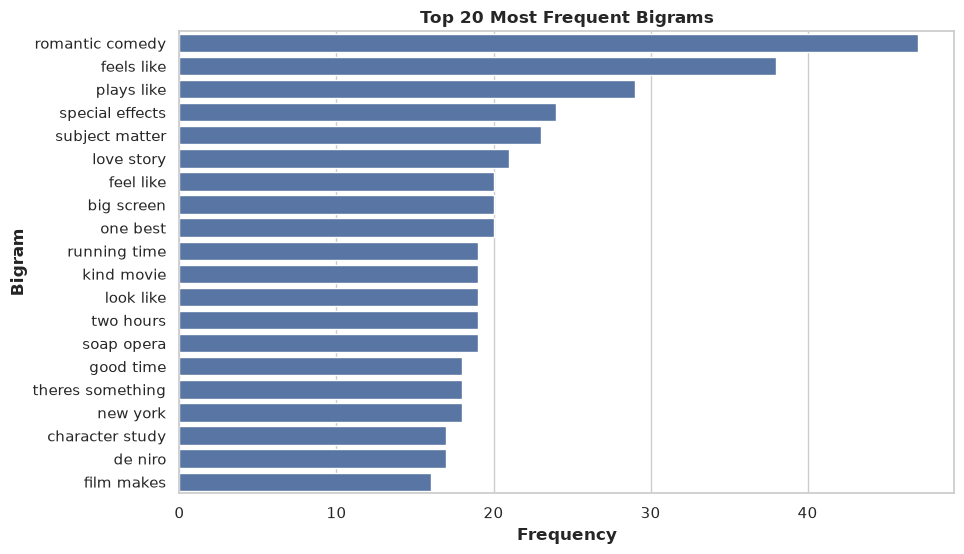

In [36]:
# Bar plot of the top 20 most common bigrams
sns.barplot(
    data=top_bigrams_df,
    x="frequency",
    y="ngram"
)

plt.title("Top 20 Most Frequent Bigrams", weight="bold")
plt.xlabel("Frequency", weight="bold")
plt.ylabel("Bigram", weight="bold")

plt.savefig(FIGURES_DIR / "top_20_bigrams.png")

plt.show()

In [37]:
# Get the top 20 most common trigrams
top_trigrams_df = get_top_ngrams(train_df["tokens"], n=3, top_n=20)

# Convert the n-grams from tuples to strings for better readability
top_trigrams_df["ngram"] = (
    top_trigrams_df["ngram"]
    .apply(lambda x: " ".join(x))
)

top_trigrams_df.head()

,ngram,frequency
0,big fat greek,10
1,fat greek wedding,10
2,sweet home alabama,8
3,eight legged freaks,7
4,trouble every day,6


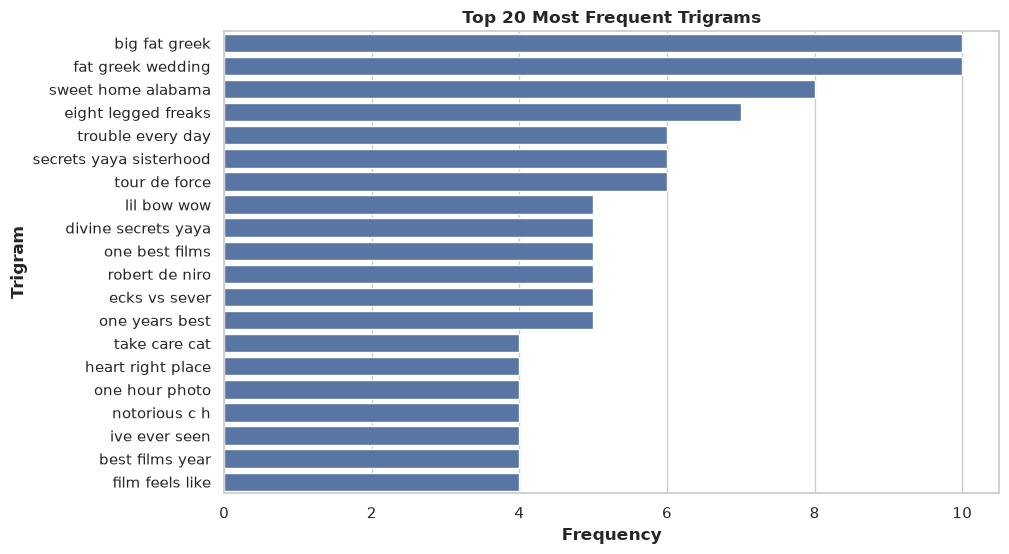

In [38]:
# Bar plot of the top 20 most common trigrams
sns.barplot(
    data=top_trigrams_df,
    x="frequency",
    y="ngram"
)

plt.title("Top 20 Most Frequent Trigrams", weight="bold")
plt.xlabel("Frequency", weight="bold")
plt.ylabel("Trigram", weight="bold")

plt.savefig(FIGURES_DIR / "top_20_trigrams.png")

plt.show()

In [39]:
# Get the top 20 bigrams from the positive reviews 
positive_bigrams_df = get_top_ngrams(positive_df["tokens"], n=2, top_n=20)

# Convert the n-grams from tuples to strings
positive_bigrams_df["ngram"] = (
    positive_bigrams_df["ngram"]
    .apply(lambda x: " ".join(x))
)

positive_bigrams_df.head()

,ngram,frequency
0,romantic comedy,33
1,one best,19
2,love story,16
3,good time,14
4,subject matter,14


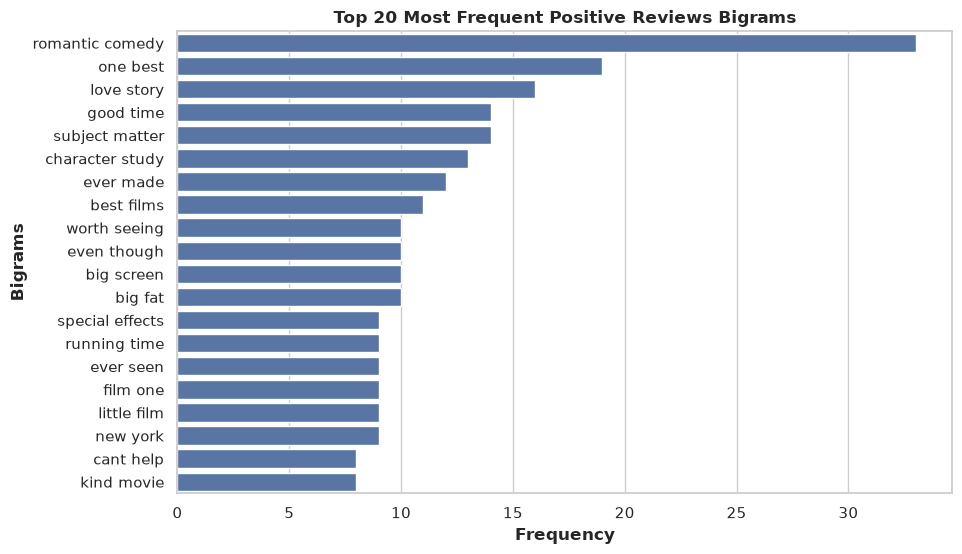

In [40]:
# Bar plot of the top 20 most common postive reviews bigrams
sns.barplot(
    data=positive_bigrams_df,
    x="frequency",
    y="ngram"
)

plt.title("Top 20 Most Frequent Positive Reviews Bigrams", weight="bold")
plt.xlabel("Frequency", weight="bold")
plt.ylabel("Bigrams", weight="bold")

plt.savefig(FIGURES_DIR / "top_20_Positive_Bigrams.png")

plt.show()

In [41]:
# Get the top 20 bigrams from the negative reviews 
negative_bigrams_df = get_top_ngrams(negative_df["tokens"], n=2, top_n=20)

# Convert the n-grams from tuples to strings
negative_bigrams_df["ngram"] = (
    negative_bigrams_df["ngram"]
    .apply(lambda x: " ".join(x))
)

negative_bigrams_df.head()

,ngram,frequency
0,feels like,34
1,plays like,26
2,soap opera,16
3,special effects,15
4,romantic comedy,14


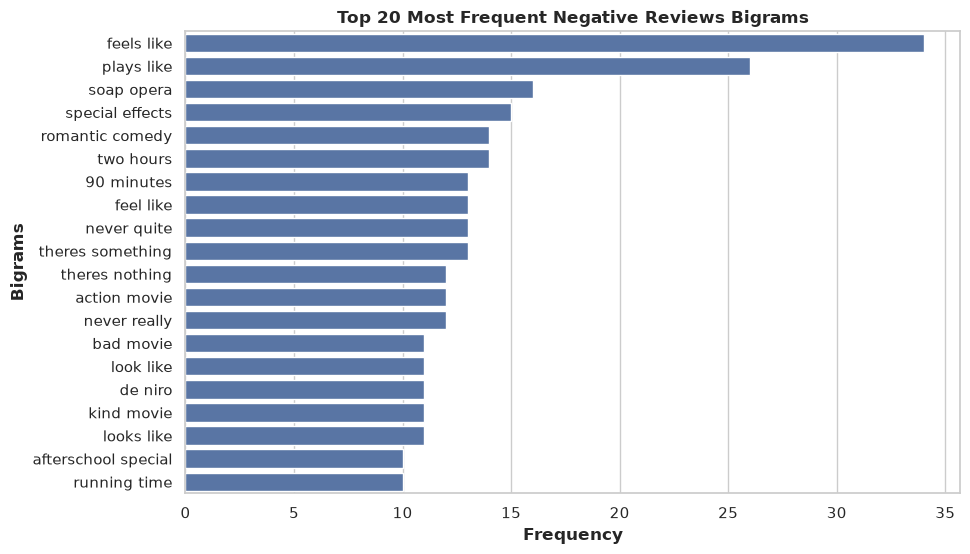

In [42]:
# Bar plot of the top 20 most common negative reviews bigrams
sns.barplot(
    data=negative_bigrams_df,
    x="frequency",
    y="ngram"
)

plt.title("Top 20 Most Frequent Negative Reviews Bigrams", weight="bold")
plt.xlabel("Frequency", weight="bold")
plt.ylabel("Bigrams", weight="bold")

plt.savefig(FIGURES_DIR / "top_20_Negative_Bigrams.png")

plt.show()

# Section 6: Qualitative Analysis of Reviews

In [43]:
# Print 5 random examples of positive reviews
positive_examples = positive_df["text"].sample(5, random_state=42)

for i, example in enumerate(positive_examples, 1):
    print(f"Positive Review Example {i}:\n{example}\n")

Positive Review Example 1:
a playful iranian parable about openness , particularly the need for people of diverse political perspectives to get along despite their ideological differences .

Positive Review Example 2:
spielberg's first real masterpiece , it deserved all the hearts it won -- and wins still , 20 years later .

Positive Review Example 3:
an amusing , breezily apolitical documentary about life on the campaign trail .

Positive Review Example 4:
there's back-stabbing , inter-racial desire and , most importantly , singing and dancing .

Positive Review Example 5:
it's all stitched together with energy , intelligence and verve , enhanced by a surplus of vintage archive footage .



In [44]:
# Print 5 random examples of negative reviews

negative_examples = negative_df["text"].sample(5, random_state=42)

for i, example in enumerate(negative_examples, 1):
    print(f"Negative Review Example {i}: \n{example}\n")

Negative Review Example 1: 
just because it really happened to you , honey , doesn't mean that it's interesting to anyone else .

Negative Review Example 2: 
this rather unfocused , all-over-the-map movie would be a lot better if it pared down its plots and characters to a few rather than dozens . . . or if it were subtler . . . or if it had a sense of humor .

Negative Review Example 3: 
there are few things more frustrating to a film buff than seeing an otherwise good movie marred beyond redemption by a disastrous ending .

Negative Review Example 4: 
the notion that bombing buildings is the funniest thing in the world goes entirely unexamined in this startlingly unfunny comedy .

Negative Review Example 5: 
a sleek advert for youthful anomie that never quite equals the sum of its pretensions .



In [45]:
# Potential Ambiguous Reviews: Reviews containing the word "not" can be ambiguous in sentiment, as they may express a negative sentiment in a positive context or vice versa.
potential_ambigious_examples = train_df[
  train_df["clean_text"].str.contains(r"\bnot\b", regex=True)
 ]

for i, example in enumerate(potential_ambigious_examples["text"].sample(5, random_state=42), 1):
    print(f"Potential Ambiguous Review Example {i}: \n{example}\n")

Potential Ambiguous Review Example 1: 
the problem with the mayhem in formula 51 is not that it's offensive , but that it's boring .

Potential Ambiguous Review Example 2: 
unfortunately , it's also not very good . especially compared with the television series that inspired the movie .

Potential Ambiguous Review Example 3: 
as a tolerable diversion , the film suffices ; a triumph , however , it is not .

Potential Ambiguous Review Example 4: 
looking aristocratic , luminous yet careworn in jane hamilton's exemplary costumes , rampling gives a performance that could not be improved upon .

Potential Ambiguous Review Example 5: 
with not a lot of help from the screenplay ( proficient , but singularly cursory ) , [testud] acts with the feral intensity of the young bette davis .



# Planned Benchmark Pipeline

The remainder of this project will evaluate multiple approaches to text classification, progressing from traditional machine learning models to transformer-based models and finally to large language models.

All approaches will be evaluated using consistent preprocessing pipeline and common evaluatoion metrics to enable fair comparisons.